<h1 style="text-align: center;">Sequential Monte Carlo with Likelihood Annealing</h1>

---

## 1. Motivation

Recall that the posterior distribution is defined by Bayes' rule as

$$
\pi(\theta) \equiv p(\theta \mid y) \propto p(y \mid \theta)\, p(\theta)
$$

where $p(\theta)$ denotes the prior distribution and $p(y \mid \theta)$ is the likelihood.

Although the posterior is straightforward to express up to proportionality, drawing samples from it can be computationally difficult. In particular, the posterior may be

- highly concentrated
- strongly correlated
- multimodal or
- separated from the prior by regions of very low probability

These features can cause standard sampling methods to mix slowly or fail to explore the full posterior. Sequential Monte Carlo (SMC) addresses this difficulty by introducing a sequence of intermediate distributions that gradually transform the prior into the posterior, through a procedure known as likelihood annealing (or tempering).

## 2. Likelihood Annealing

To approximate the posterior $\pi(\theta)$, SMC begins by sampling $N$ weighted particles

$$
\{W_0^j, \theta_0^j\}_{j=1}^{N}
$$

from an initial distribution $\pi_0(\theta)$ that is easy to sample from, typically the prior $p(\theta)$. These particles are then propagated through a sequence of intermediate target distributions $\{\pi_t(\theta)\}_{t=1}^{T}$ that progressively bridge the initial distribution and the posterior, with $\pi_T(\theta) = \pi(\theta)$.

Under likelihood annealing, the intermediate distributions are defined as

$$
\pi_t(\theta) \equiv \pi_t(\theta \mid y_{1:T}) \propto p(y_{1:T} \mid \theta)^{\beta_t} \, p(\theta)
$$

where $\beta_t$ is an inverse-temperature parameter satisfying

$$
0 = \beta_0 < \beta_1 < \cdots < \beta_T = 1
$$

Endpoints of the schedule.

| Stage | Target | Interpretation |
|---|---|---|
| $\beta_0 = 0$ | $\pi_0(\theta) \propto p(\theta)$ | The likelihood contributes no information; the target is the prior |
| $0 < \beta_t < 1$ | $\pi_t(\theta) \propto p(y \mid \theta)^{\beta_t} p(\theta)$ | The likelihood is introduced gradually |
| $\beta_T = 1$ | $\pi_T(\theta) \propto p(y \mid \theta) p(\theta) = \pi(\theta)$ | The full likelihood is recovered: the posterior |

As $\beta_t$ increases, the likelihood is faded in and the particle population moves toward regions of higher posterior probability. The tempering parameter therefore controls the difficulty of each transition, gradually transforming an easy-to-sample initial distribution into the more complex posterior target.

This avoids moving particles directly from the prior to a potentially complex and highly concentrated posterior, which would cause severe weight degeneracy and leave only a handful of particles carrying meaningful probability mass. By introducing the likelihood gradually, SMC maintains a more diverse particle population and produces a more stable approximation of the posterior.

## 3. The SMC Algorithm

In esscene, the SMC algorithm evolves a population of $N$ particles $\{x_t^i\}_{i=1}^{N}$ through the schedule. Each stage $t$ consists of three steps:

**1. Reweight.** Update each particle's importance weight to reflect the move from $\pi_{\beta_{t-1}}$ to $\pi_{\beta_t}$:

$$
\tilde{w}_t^{\,i} = w_{t-1}^{\,i} \cdot L\big(x_{t-1}^i\big)^{\,\beta_t - \beta_{t-1}}
\qquad
W_t^{\,i} = \frac{\tilde{w}_t^{\,i}}{\sum_{j=1}^{N} \tilde{w}_t^{\,j}}
$$

**2. Resample.** If the particle population has degenerated, draw $N$ particles from the current set with probabilities $\{W_t^{\,i}\}$. This discards low-weight particles, duplicates high-weight ones, and yields an equally weighted sample.

**3. Mutate.** Refresh each resampled particle by running $K$ Metropolis–Hastings steps whose stationary distribution is the current tempered target $\pi_{\beta_t}$; This reintroduces diversity and lets particles move toward whichever mode they are near.

<div style="text-align: center;">
  <img src="SMC.png?v=2" alt="Sequential Monte Carlo" width="500">
</div>

## 4. A Note on Log-Space Computation

In the implementations below, all calculations are performed using log-densities rather than densities directly. This is a standard numerical safeguard in SMC, where likelihood values and particle weights can become extremely small. Recall,

Products become sums. The tempered target is

$$
\pi_\beta(x) \propto p_0(x)\, L(x)^\beta
\qquad\Longrightarrow\qquad
\log \pi_\beta(x) = \log p_0(x) + \beta \log L(x) 
$$

Note that $\beta$ now appears as a multiplier rather than an exponent.

Ratios become differences. Both the reweighting step and the MH mutation step involve ratios of densities. In log-space:

$$
\log \tilde{w}_t^{\,i} = \log w_{t-1}^{\,i} + (\beta_t - \beta_{t-1}) \log L\big(x_{t-1}^{\,i}\big),
\qquad
\log \alpha = \log \pi_{\beta_t}(x^\ast) - \log \pi_{\beta_t}(x)
$$

For a symmetric proposal, the MH step accepts whenever

$$
\log u < \min(0, \log \alpha), \qquad u \sim \mathcal{U}(0,1)
$$

Log-sum-exp normalization. When normalized weights are required, the largest log-weight is subtracted before exponentiating:

$$
W_t^i = \frac{\exp\!\big(\log \tilde{w}_t^{\,i} - m\big)}{\sum_{j=1}^{N} \exp\!\big(\log \tilde{w}_t^{\,j} - m\big)},
\qquad
m = \max_j \log \tilde{w}_t^{\,j}
$$

Subtracting the same constant from every log-weight leaves the normalized weights unchanged but prevents overflow and underflow.

## 5. Weight Degeneracy and Effective Sample Size

Even when weights are computed accurately in log-space, an SMC sampler can still suffer weight degeneracy: a small number of particles receive nearly all of the probability mass while the rest have weights close to zero. The sample may contain many particles, but only a few contribute meaningfully to posterior estimates.

The severity is measured by the effective sample size:

$$
\operatorname{ESS}_t = \frac{1}{\sum_{i=1}^{N} (W_t^i)^2},
\qquad
1 \leq \operatorname{ESS}_t \leq N
$$

- If all particles have equal weights, $W_t^i = 1/N$, then $\operatorname{ESS}_t = N$
- If one particle carries nearly all the weight, $\operatorname{ESS}_t \to 1$

When the ESS falls below a chosen threshold,

$$
\operatorname{ESS}_t < cN, \qquad 0 < c < 1
$$

the particles are resampled according to their normalized weights: large-weight particles are likely duplicated, negligible-weight particles are likely discarded. Afterwards the weights are reset to $W_t^i = 1/N$.

Ultimately, resampling prevents a handful of particles from permanently dominating the approximation. 

---

# Example 1: Sampling from a Bimodal Target

Suppose we wish to sample from the following bimodal density, a mixture of two Gaussian components:

$$
f(x) = \delta \, \mathcal{N}(x \mid \mu_1, \sigma_1^2) + (1 - \delta)\, \mathcal{N}(x \mid \mu_2, \sigma_2^2),
$$

with $\mu_1 = 3$, $\mu_2 = 15$, $\sigma_1 = \sigma_2 = 0.5$ and $\delta = 0.7$

The two modes are separated by a wide region of essentially zero density, so a single Metropolis–Hastings chain started near one mode will almost never cross to the other. SMC handles this by treating $f$ as the (unnormalized) likelihood $L$ and pairing it with a broad prior $p_0$, so that early stages of the schedule are easy to explore.

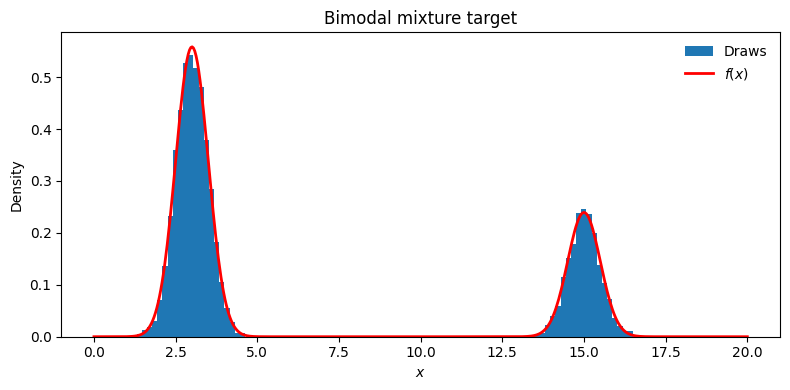

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(0)

delta_true  = 0.7
mu1_true, sigma1_true = 3.0, 0.5
mu2_true, sigma2_true = 15.0, 0.5

n = 10000
component = rng.random(n) < delta_true
draws = np.where(
    component,
    rng.normal(mu1_true, sigma1_true, size=n),
    rng.normal(mu2_true, sigma2_true, size=n),
)

grid = np.linspace(0, 20, 500)
density = (delta_true * norm.pdf(grid, mu1_true, sigma1_true)
           + (1 - delta_true) * norm.pdf(grid, mu2_true, sigma2_true))

plt.figure(figsize=(8, 4))
plt.hist(draws, bins=100, density=True, label="Draws")
plt.plot(grid, density, "r-", lw=2, label=r"$f(x)$")
plt.title("Bimodal mixture target")
plt.xlabel("$x$")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 1.1 The Sampler

In [2]:
#initial parameters
N = 2000                       # number of particles
K = 5                          # MCMC steps per stage
T = 20                         # number of betas in the tempering schedule
c = 0.8                        # ESS threshold as a fraction of N
betas = np.linspace(0, 1, T)   # tempering schedule
prior = norm(loc=10, scale=10) # prior distribution



def L(x, delta=delta_true):
    '''Mixture-of-two-Gaussians density, used here as the likelihood.'''
    return delta * norm.pdf(x, loc=mu1_true, scale=sigma1_true) + (1 - delta) * norm.pdf(x, loc=mu2_true, scale=sigma2_true)


def log_L(x):
    '''Log-likelihood (small constant guards against log(0)).'''
    return np.log(L(x) + 1e-300)


def log_pi(x, beta):
    '''Log of the tempered target: log p_0(x) + beta * log L(x).'''
    return prior.logpdf(x) + beta * log_L(x)

def resample(particles, weights):
    '''Multinomial resampling of particles according to their weights.'''
    idx = rng.choice(len(particles), size=len(particles), p=weights)
    return particles[idx]


def mutate(particles, beta, n_mcmc=K, proposal_std=1.0):
    '''Random-walk Metropolis-Hastings steps targeting pi_beta.'''
    for _ in range(n_mcmc):
        proposal = particles + rng.normal(0, proposal_std, size=len(particles))
        log_alpha = log_pi(proposal, beta) - log_pi(particles, beta)
        accept = np.log(rng.random(len(particles))) < log_alpha
        particles[accept] = proposal[accept]
    return particles


particles = prior.rvs(size=N, random_state=0)  # initialize from the prior
weights = np.ones(N) / N                       # uniform initial weights
snapshots = [(0.0, particles.copy())]

for t in range(1, T):
    # 1. Reweight
    log_w = np.log(weights + 1e-300) + (betas[t] - betas[t - 1]) * log_L(particles)
    weights = np.exp(log_w)
    weights /= weights.sum()

    # 2. Resample if the ESS has fallen too low
    ESS = 1.0 / np.sum(weights ** 2)
    if ESS < c * N:
        particles = resample(particles, weights)
        weights = np.ones(N) / N

    # 3. Mutate
    particles = mutate(particles, betas[t])
    snapshots.append((betas[t], particles.copy()))

print("SMC completed!")

SMC completed!


## 1.2 Watching the Particles Anneal

The panels below show the particle population at six points along the schedule, together with the tempered target $\pi_\beta$ at that stage. At $\beta = 0$ the particles are simply prior draws; as $\beta \to 1$ they migrate into the two modes and recover the correct $70/30$ weighting.

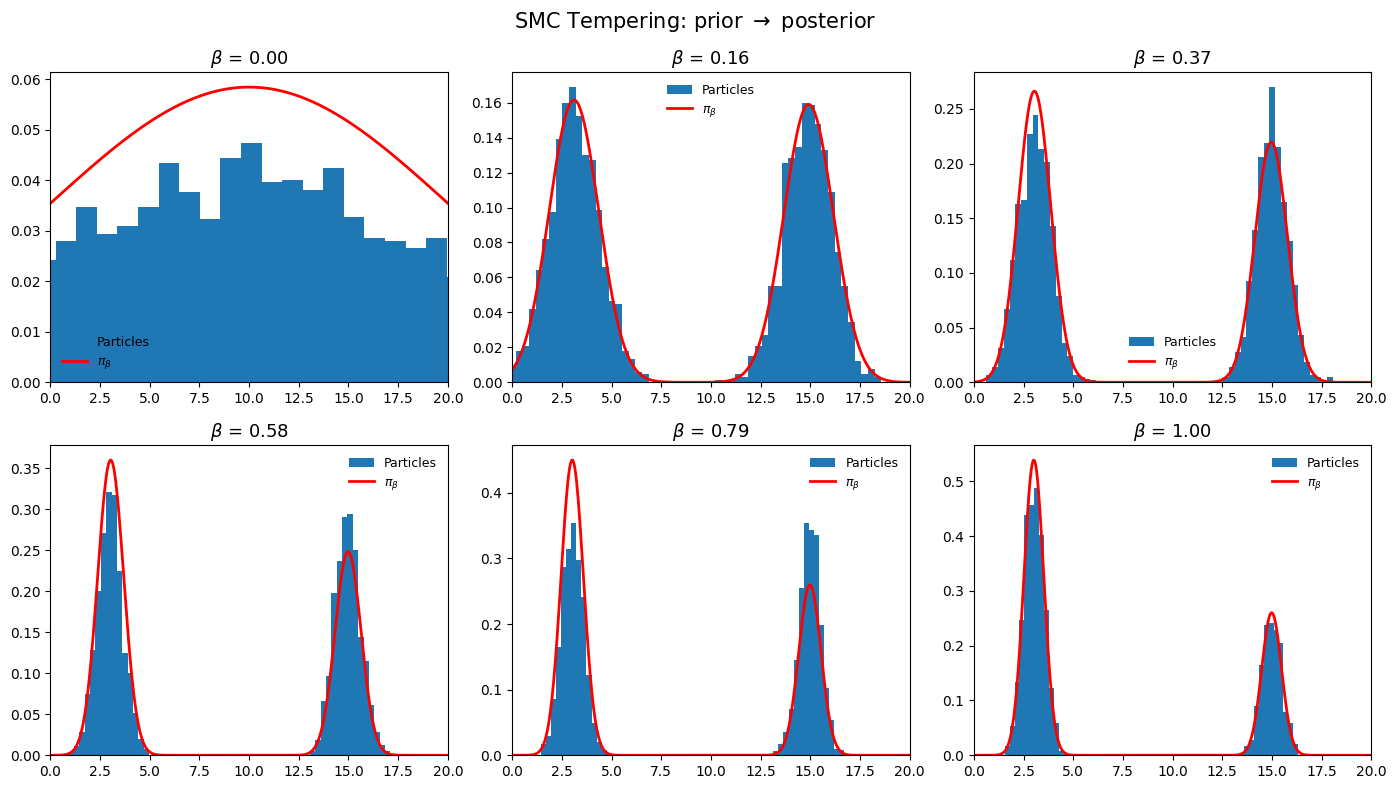

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
stage_indices = np.linspace(0, len(snapshots) - 1, 6, dtype=int)
x_grid = np.linspace(0, 20, 500)

for ax, idx in zip(axes.flat, stage_indices):
    beta, pts = snapshots[idx]

    ax.hist(pts, bins=60, density=True, label="Particles")

    log_p = log_pi(x_grid, beta)
    p = np.exp(log_p - log_p.max())
    p /= np.trapezoid(p, x_grid)
    ax.plot(x_grid, p, "r-", lw=2, label=r"$\pi_\beta$")

    ax.set_title(rf"$\beta$ = {beta:.2f}", fontsize=13)
    ax.set_xlim(0, 20)
    ax.legend(fontsize=9, framealpha=0, loc=0)

fig.suptitle("SMC Tempering: prior $\\rightarrow$ posterior", fontsize=15)
plt.tight_layout()
plt.show()

---

# Example 2: Estimating the Mixture Parameters

In Example 1 the mixture parameters were known and the sampler explored a single unknown $x$. We now flip the problem: the draws from Example 1 are the observed data, and the five generating parameters are unknown:

$$
\theta = (\delta,\ \mu_1,\ \sigma_1,\ \mu_2,\ \sigma_2)
$$

Each SMC particle $\theta^{(m)}$, $m = 1,\dots,N$, is one candidate parameter vector for the two-component model.

## 2.1 Model and Log-Likelihood

Conditional on $\theta$, each observation is drawn independently from the mixture, so its density splits into the two component contributions

$$
p(y_i \mid \theta)
= \underbrace{\delta\,\mathcal{N}(y_i \mid \mu_1, \sigma_1^2)}_{A_i}
+ \underbrace{(1-\delta)\,\mathcal{N}(y_i \mid \mu_2, \sigma_2^2)}_{B_i}.
$$

Gaussian densities underflow in the tails, so each term is formed in log-space,

$$
a_i = \log\delta + \log\mathcal{N}(y_i \mid \mu_1, \sigma_1^2),
\qquad
b_i = \log(1-\delta) + \log\mathcal{N}(y_i \mid \mu_2, \sigma_2^2),
$$

and recombined with the **log-sum-exp** identity $\log(e^a + e^b) = \max(a,b) + \log\!\big(e^{a-\max} + e^{b-\max}\big)$ — the `np.logaddexp(a, b)` operation. By conditional independence the full-sample log-likelihood is the sum over observations:

$$
\ \ell(\theta) = \sum_{i=1}^{n} \operatorname{logaddexp}(a_i,\, b_i)
$$

## 2.2 Priors

$$
\delta \sim \text{Beta}(1,1), \qquad
\mu_1, \mu_2 \sim \mathcal{N}(10, 10^2), \qquad
\sigma_1, \sigma_2 \sim \text{Half-Normal}(5).
$$

## 2.3 Why SMC Fits Here

Two features make this posterior awkward for a naive sampler:

1. **Label switching.** The likelihood is invariant under swapping the components — $(\delta, \mu_1, \sigma_1, \mu_2, \sigma_2)$ and $(1-\delta, \mu_2, \sigma_2, \mu_1, \sigma_1)$ are identical — so the posterior is **bimodal**. We break the symmetry with the constraint $\mu_1 < \mu_2$ (zero prior density otherwise).
2. **Concentration.** With $n = 10{,}000$ observations the likelihood is far sharper than the priors — exactly the prior/posterior mismatch that annealing is designed to bridge.

## 2.4 Unconstrained Parameters

$\delta \in (0,1)$ and $\sigma_j > 0$, so a random-walk proposal would repeatedly step outside the support. We instead store particles on an unconstrained scale $\tilde\theta = (\tilde\delta, \mu_1, \tilde\sigma_1, \mu_2, \tilde\sigma_2) \in \mathbb{R}^5$ and recover the constrained values via

$$
\delta = \operatorname{logit}^{-1}(\tilde\delta),
\qquad
\sigma_j = \exp(\tilde\sigma_j).
$$



## 2.5 The Log Prior

Recall in Section 2.2 we specified the priors on the constrained scale, but the sampler works with the unconstrained particles $\tilde\theta$. More specifically, we have a probability density function $p(\theta)$ defined on a constrained space, and we want to sample from an unconstrained space using the mapping $\theta = g(\tilde{\theta})$, the probability density on the new unconstrained space $p(\tilde{\theta})$ is given by the change of variables formula:

$$
p(\tilde\theta) = p\big(g(\tilde\theta)\big)\,\left| \frac{d\theta}{d\tilde\theta} \right|
$$

The Jacobian factor corrects for how the transform stretches or compresses volume; dropping it would silently bias the posterior.

Now, only $\delta$ and the two $\sigma_j$ are transformed ($\mu_1, \mu_2$ are left as-is), and each transform acts on a single coordinate, so the Jacobian is diagonal and factorizes:

$$
\left| \frac{d\theta}{d\tilde\theta} \right|
= \left| \frac{d\delta}{d\tilde\delta} \right|
\cdot \left| \frac{d\sigma_1}{d\tilde\sigma_1} \right|
\cdot \left| \frac{d\sigma_2}{d\tilde\sigma_2} \right|
$$

**Weight** — with $\delta = \operatorname{logit}^{-1}(\tilde\delta)$, the inverse-logit derivative is

$$
\frac{d\delta}{d\tilde\delta} = \frac{e^{-\tilde\delta}}{(1 + e^{-\delta})^2}= \delta(1-\delta)
\quad\Longrightarrow\quad
\log\left|\frac{d\delta}{d\tilde\delta}\right| = \log\delta + \log(1-\delta)
$$

**Scales** — with $\sigma_j = \exp(\tilde\sigma_j)$,

$$
\frac{d\sigma_j}{d\tilde\sigma_j} = \exp(\tilde\sigma_j) = \sigma_j
\quad\Longrightarrow\quad
\log\left|\frac{d\sigma_j}{d\tilde\sigma_j}\right| = \tilde\sigma_j
$$

Taking logarithms of the change-of-variables formula turns the product into a sum of the constrained-scale log-priors and these log-Jacobians:

$$
\log p(\tilde\theta) =
\underbrace{\log p(\mu_1) + \log p(\mu_2)}_{\mathcal{N}(10,\,10^2)}
+ \underbrace{\log p(\sigma_1) + \log p(\sigma_2)}_{\text{Half-Normal}(5)}
+ \underbrace{\log p(\delta)}_{\text{Beta}(1,1)}
+ \log\delta + \log(1-\delta) + \tilde\sigma_1 + \tilde\sigma_2
$$

Two simplifications match the log_prior function below:

- $\delta \sim \text{Beta}(1,1)$ is uniform, so $\log p(\delta)$ is constant and is dropped $\left(p(\delta)
=
\frac{\delta^{\alpha-1}(1-\delta)^{\beta-1}}
{B(\alpha,\beta)}, \; p(\delta) = 1 \implies \log p(\delta) = 0 \right)$. However, its Jacobian term $\log\delta + \log(1-\delta)$ is not constant — under the transform a uniform $\delta$ becomes a logistic density on $\tilde\delta$.
- A Half-Normal(5) density equals $2\,\mathcal{N}(\sigma_j \mid 0, 5^2)$ for $\sigma_j > 0$, contributing the $+\log 2$ per scale.

Finally, the identifiability constraint $\mu_1 < \mu_2$ is enforced by setting $\log p(\tilde\theta) = -\infty$ wherever it is violated. Assembling these terms gives

$$
\log p(\tilde\theta) =
\log\mathcal{N}(\mu_1\!\mid\!10,10^2) + \log\mathcal{N}(\mu_2\!\mid\!10,10^2)
+ \sum_{j=1}^{2}\big[\log 2 + \log\mathcal{N}(\sigma_j\!\mid\!0,5^2) + \tilde\sigma_j\big]
+ \log\delta + \log(1-\delta)
$$

for $\mu_1 < \mu_2$, and $-\infty$ otherwise.

In [4]:
from scipy.special import expit, logit

y = draws                              # observed data
prior_mu = norm(loc=10, scale=10)      # prior on mu_1, mu_2
prior_sigma_scale = 5.0                # half-normal scale on sigma_1, sigma_2


def unpack(theta):
    '''Map unconstrained particles -> (delta, mu1, sigma1, mu2, sigma2).'''
    delta  = expit(theta[:, 0])
    mu1    = theta[:, 1]
    sigma1 = np.exp(theta[:, 2])
    mu2    = theta[:, 3]
    sigma2 = np.exp(theta[:, 4])
    return delta, mu1, sigma1, mu2, sigma2


def log_prior(theta):
    '''Log prior on the unconstrained scale'''
    delta, mu1, sigma1, mu2, sigma2 = unpack(theta)

    lp  = prior_mu.logpdf(mu1) + prior_mu.logpdf(mu2)               # mu priors
    lp += norm.logpdf(sigma1, 0, prior_sigma_scale) + np.log(2)     
    lp += norm.logpdf(sigma2, 0, prior_sigma_scale) + np.log(2)
    lp += np.log(delta) + np.log(1 - delta)                        # logit Jacobian
    lp += theta[:, 2] + theta[:, 4]                                # log Jacobians (sigmas) 
    return np.where(mu1 < mu2, lp, -np.inf)                        # identifiability


def log_L(theta):
    '''Mixture log-likelihood of the full dataset, one value per particle.'''
    delta, mu1, sigma1, mu2, sigma2 = unpack(theta)
    a = np.log(delta)[:, None]   + norm.logpdf(y[None, :], mu1[:, None], sigma1[:, None])
    b = np.log1p(-delta)[:, None] + norm.logpdf(y[None, :], mu2[:, None], sigma2[:, None])
    return np.logaddexp(a, b).sum(axis=1)


def log_pi(theta, beta):
    '''Log of the tempered posterior: log p(theta) + beta * log L(theta).'''
    lp = log_prior(theta)
    return np.where(np.isfinite(lp), lp + beta * log_L(theta), -np.inf)

## 2.6 Running the Sampler

The algorithm is structurally identical to Example 1 — reweight, resample, mutate — but with three practical upgrades that are worth noting:

- **Adaptive schedule.** Instead of a fixed grid of $\beta$'s, each step solves for the next $\beta_t$ that drops the ESS to exactly $cN$ (by bisection). The sampler takes small steps where the target changes quickly and large steps where it does not.
- **Adaptive proposal.** The MH proposal covariance is set to $2.38^2/d$ times the empirical covariance of the current particles, the standard scaling for random-walk Metropolis in $d$ dimensions.
- **Cached log-likelihoods.** The likelihood is a sum over 10,000 observations, so it is evaluated once per particle per stage and reused in the reweighting step.

In [5]:
#initial parameters
N = 1000                       # number of particles
K = 10                         # MCMC steps per stage
c = 0.5                        # ESS threshold as a fraction of N
d = 5                          # dimension of particles


def next_beta(beta, particles, weights):
    '''Smallest beta > beta whose reweighting drops the ESS to c*N (bisection).'''
    log_L_vals = log_L(particles)
    log_w0 = np.log(weights + 1e-300)

    def ess_at(beta_new):
        lw = log_w0 + (beta_new - beta) * log_L_vals
        lw -= lw.max()
        w = np.exp(lw); w /= w.sum()
        return 1.0 / np.sum(w ** 2)

    if ess_at(1.0) >= c * N:           
        return 1.0
    lo, hi = beta, 1.0
    while hi - lo > 1e-6:
        mid = 0.5 * (lo + hi)
        hi, lo = (mid, lo) if ess_at(mid) < c * N else (hi, mid)
    return hi


def resample(particles, weights):
    '''Multinomial resampling of particles according to their weights.'''
    idx = rng.choice(len(particles), size=len(particles), p=weights)
    return particles[idx]


def mutate(particles, beta, n_mcmc=K):
    '''Random-walk Metropolis-Hastings steps targeting pi_beta.'''
    chol = np.linalg.cholesky((2.38 ** 2 / d) * (np.cov(particles.T) + 1e-6 * np.eye(d)))
    log_pi_cur = log_pi(particles, beta)
    for _ in range(n_mcmc):
        proposal = particles + rng.standard_normal((len(particles), d)) @ chol.T
        log_pi_new = log_pi(proposal, beta)
        log_alpha = log_pi_new - log_pi_cur
        accept = np.log(rng.random(len(particles))) < log_alpha
        particles[accept] = proposal[accept]
        log_pi_cur[accept] = log_pi_new[accept]
    return particles


# initialize particles from the prior 
particles = np.column_stack([
    logit(rng.uniform(0.01, 0.99, N)),                           # delta 
    prior_mu.rvs(N, random_state=1),                             # mu1
    np.log(np.abs(rng.normal(0, prior_sigma_scale, N)) + 1e-3),  # log sigma1
    prior_mu.rvs(N, random_state=2),                             # mu2
    np.log(np.abs(rng.normal(0, prior_sigma_scale, N)) + 1e-3),  # log sigma2
])

lo_mu = np.minimum(particles[:, 1], particles[:, 3])
hi_mu = np.maximum(particles[:, 1], particles[:, 3])
particles[:, 1], particles[:, 3] = lo_mu, hi_mu

weights = np.ones(N) / N                      
beta = 0.0                                      
snapshots = [(0.0, particles.copy())]

while beta < 1.0:
    beta_next = next_beta(beta, particles, weights)  

    # 1. Reweight
    log_w = np.log(weights + 1e-300) + (beta_next - beta) * log_L(particles)
    log_w -= log_w.max()                       # log-sum-exp stabilization
    weights = np.exp(log_w)
    weights /= weights.sum()

    # 2. Resample if the ESS has fallen too low
    ESS = 1.0 / np.sum(weights ** 2)
    if ESS < c * N:
        particles = resample(particles, weights)
        weights = np.ones(N) / N

    # 3. Mutate
    beta = beta_next
    particles = mutate(particles, beta)
    snapshots.append((beta, particles.copy()))

print("SMC completed!")

SMC completed!


## 2.7 Posterior Summaries

The particles at $\beta = 1$ are an (approximately) equally weighted sample from $p(\theta \mid y)$. Transforming them back to the constrained scale gives posterior means and credible intervals for all five parameters, which we compare against the values that actually generated the data.

In [6]:
import pandas as pd

delta_s, mu1_s, sigma1_s, mu2_s, sigma2_s = unpack(particles)
posterior = {
    "delta":   delta_s,
    "mu_1":    mu1_s,
    "sigma_1": sigma1_s,
    "mu_2":    mu2_s,
    "sigma_2": sigma2_s,
}
truth = {
    "delta":   delta_true,
    "mu_1":    mu1_true,
    "sigma_1": sigma1_true,
    "mu_2":    mu2_true,
    "sigma_2": sigma2_true
}

summary = pd.DataFrame({
    "true":            [truth[k] for k in posterior],
    "posterior mean":  [s.mean() for s in posterior.values()],
    "posterior sd":    [s.std()  for s in posterior.values()],
    "2.5%":            [np.percentile(s,  2.5) for s in posterior.values()],
    "97.5%":           [np.percentile(s, 97.5) for s in posterior.values()],
}, index=list(posterior)).round(3)

summary

,true,posterior mean,posterior sd,2.5%,97.5%
delta,0.7,0.700,0.005,0.691,0.709
mu_1,3.0,3.002,0.006,2.989,3.014
sigma_1,0.5,0.497,0.004,0.489,0.506
mu_2,15.0,15.003,0.009,14.986,15.021
sigma_2,0.5,0.502,0.007,0.489,0.515


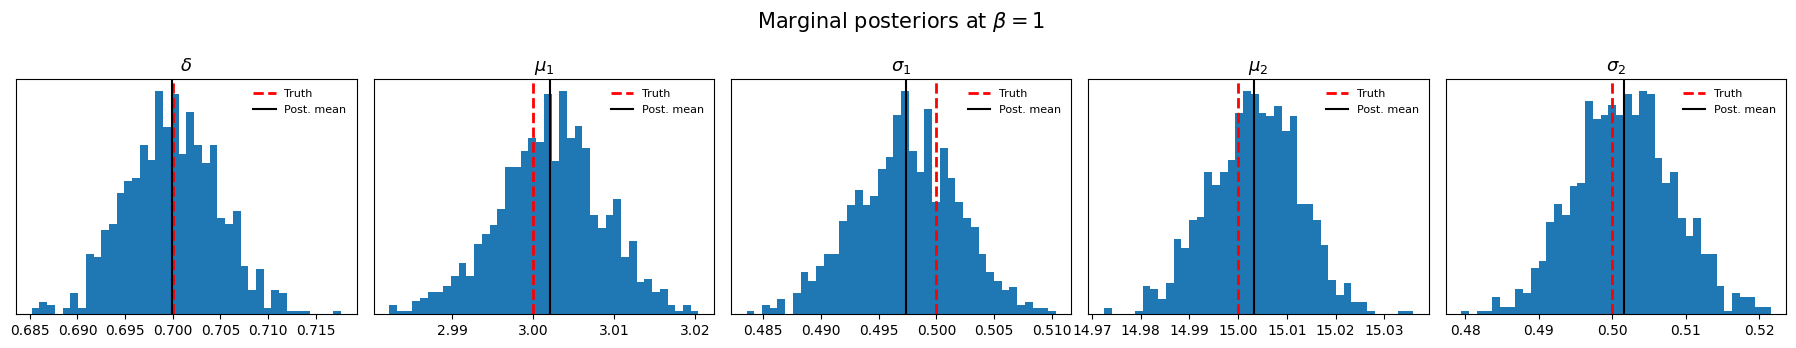

In [7]:
labels = {
    "delta":   r"$\delta$",
    "mu_1":    r"$\mu_1$",
    "sigma_1": r"$\sigma_1$",
    "mu_2":    r"$\mu_2$",
    "sigma_2": r"$\sigma_2$",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, (name, samples) in zip(axes, posterior.items()):
    ax.hist(samples, bins=40, density=True)
    ax.axvline(truth[name], color="red", ls="--", lw=2, label="Truth")
    ax.axvline(samples.mean(), color="black", ls="-", lw=1.5, label="Post. mean")
    ax.set_title(labels[name], fontsize=13)
    ax.set_yticks([])
    ax.legend(fontsize=8, framealpha=0)

fig.suptitle(r"Marginal posteriors at $\beta = 1$", fontsize=15)
plt.tight_layout()
plt.show()

## 2.8 Posterior Predictive Check

Finally, we overlay the fitted mixture density — evaluated at the posterior mean of $\theta$ — on the observed data. If the sampler has done its job, the two should be indistinguishable.

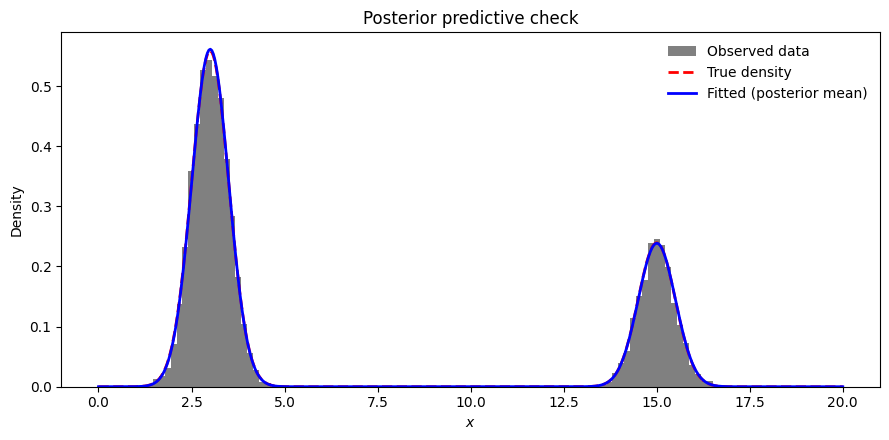

In [8]:
x_grid = np.linspace(0, 20, 500)

fitted = (posterior["delta"].mean()
          * norm.pdf(x_grid, posterior["mu_1"].mean(), posterior["sigma_1"].mean())
          + (1 - posterior["delta"].mean())
          * norm.pdf(x_grid, posterior["mu_2"].mean(), posterior["sigma_2"].mean()))

true_density = (delta_true * norm.pdf(x_grid, mu1_true, sigma1_true)
                + (1 - delta_true) * norm.pdf(x_grid, mu2_true, sigma2_true))

plt.figure(figsize=(9, 4.5))
plt.hist(y, bins=100, density=True, color="grey", label="Observed data")
plt.plot(x_grid, true_density, "r--", lw=2, label="True density")
plt.plot(x_grid, fitted, "b-", lw=2, label="Fitted (posterior mean)")
plt.xlabel("$x$")
plt.ylabel("Density")
plt.title("Posterior predictive check")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

---

## References
[1] Del Moral, Pierre, Arnaud Doucet, and Ajay Jasra. "Sequential monte carlo samplers." Journal of the Royal Statistical Society Series B: Statistical Methodology 68.3 (2006): 411-436.

[2] Neal, Radford M. "Annealed importance sampling." Statistics and computing 11.2 (2001): 125-139. 